<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
Energy Market Scraping & Forecasting
 

</center></p></h1>

<div style="border-radius: 5px; -webkit-border-radius: 5px; -moz-border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF">
   <!-- Title -->
    <p style="text-align: center; font-family: cursive; font-size: 16px; color: green; font-weight: bold;">
        Energy Sector Stock & Revenue Forecasting System
    </p>
   <!-- Objective -->
    <h3 style="color:#006400; font-family: cursive; margin-top: 8px;">Objective</h3>
    <p>
        To build an end-to-end automated analytics system that tracks, compares, and forecasts financial performance of major global energy companies (Chevron, TotalEnergies, CNQ, Suncor, Shell)
        using <strong>real-time stock data</strong>, <strong>revenue web-scraping</strong>, and <strong>machine-learning forecasting models</strong>.
    </p>
 <!-- Problem -->
    <h3 style="color:#006400; font-family: cursive; margin-top: 8px;">Problem</h3>
    <p>
        Energy markets are extremely volatile. Procurement teams, analysts, and investors face three major challenges:
    </p>

 <ol>
        <li>
            <strong>Data is scattered</strong><br>
            Stock prices come from Yahoo Finance… Revenue data comes from Macrotrends… Oil benchmark prices come from different sources… Each requires manual downloading and cleaning.
        </li>
        <li style="margin-top:8px;">
            <strong>No unified system for monitoring</strong><br>
            Most organizations rely on spreadsheets updated manually → <span style="color:#990000; font-weight:bold;">slow, error-prone, and not suitable for daily decision-making.</span>
        </li>
        <li style="margin-top:8px;">
            <strong>No forecasting capability</strong><br>
            Businesses cannot reliably predict future stock trends, revenue behaviour, short-term market risk,  on corporate performance. This creates uncertainty in procurement, budgeting, and risk management.
        </li>
    </ol>
 <!-- Suggested Solution Overview -->
    <h3 style="color:#006400; font-family: cursive; margin-top: 8px;">Solution </h3>
    <p>
        Build a modular pipeline that:
    </p>
    <ul>
        <li>Ingests live stock quotes (Yahoo Finance API / yfinance) and stores time-series in a database.</li>
        <li>Scrapes and normalizes quarterly revenue tables from trusted sources (Macrotrends or company filings).</li>
        <li>Runs automated data quality checks and pipelines (ETL) daily.</li>
        <li>Generates dashboards and provides ML forecasts (short-term price & revenue scenarios).</li>
    </ul>
 <!-- Call to action -->
    <p style="margin-top: 10px;">
        <strong>Next steps:</strong> define data sources, design the ETL schema, select forecasting models (ARIMA / Prophet ), and prototype a dashboard for stakeholders.
    </p>

</div>


<div style="border-radius: 5px; -webkit-border-radius: 5px; -moz-border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF">

 <!-- Title -->
 <p style="text-align: center; font-family: cursive; font-size: 16px; color: green; font-weight: bold;">
        Energy Sector Stock & Revenue Forecasting System — Aim of the Project
    </p>

 <h3 style="color:#006400; font-family: cursive; margin-top: 8px;">Aim of the Project</h3>
    <p>
        To demonstrate advanced capabilities across the full analytics lifecycle by building a robust, automated system for energy-sector financial analysis and forecasting.
    </p>

 <ul>
        <li><strong>Data engineering</strong> — design and implement reliable pipelines for ingestion, cleaning, storage, and automation (ETL).</li>
        <li><strong>Machine learning</strong> — develop and compare forecasting models (Prophet, LSTM, and other candidate models) for prices and revenues.</li>
        <li><strong>Financial data analytics</strong> — perform time-series analysis, correlation with oil benchmarks, and scenario-based stress testing.</li>
        <li><strong>Web scraping</strong> — robust extraction and normalization of quarterly revenue and financial tables using BeautifulSoup + requests (with error handling and retry logic).</li>
        <li><strong>Visualization</strong> — interactive dashboards and visualizations using Plotly for exploration and stakeholder reporting.</li>
        <li><strong>Dashboard deployment</strong> — package and deploy dashboards (Streamlit) with scheduled updates and alerting.</li>
        <li><strong>Industrial problem-solving</strong> — demonstrate reproducible, production-ready practices for procurement, budgeting, and risk teams.</li>
    </ul>

 <p style="margin-top: 10px;">
        This project demonstrates complete ownership of the lifecycle: <strong>Data → Processing → ML → Visualization → Deployment → Automation</strong>.
    </p>

</div>


In [17]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import math



import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Use yfinance to Extract Stock Data 
</center></p></h1>

In [6]:
xom = yf.Ticker("XOM")
xom_data = xom.history(period="max")
xom_data.reset_index(inplace=True)
xom_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1962-01-02 00:00:00-05:00,0.089345,0.090009,0.089345,0.089345,902400,0.0,0.0
1,1962-01-03 00:00:00-05:00,0.089345,0.090672,0.089345,0.090672,1200000,0.0,0.0
2,1962-01-04 00:00:00-05:00,0.090672,0.091336,0.090451,0.090893,1088000,0.0,0.0
3,1962-01-05 00:00:00-05:00,0.090893,0.091336,0.088682,0.088903,1222400,0.0,0.0
4,1962-01-08 00:00:00-05:00,0.088903,0.089566,0.087576,0.088682,1388800,0.0,0.0


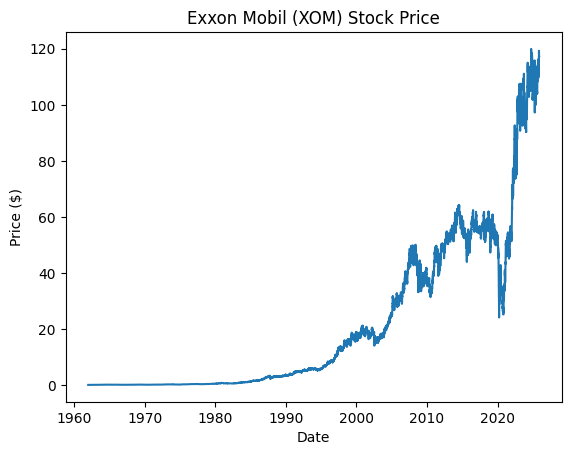

In [7]:

plt.plot(xom_data['Date'], xom_data['Close'])
plt.title("Exxon Mobil (XOM) Stock Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

In [ ]:
#Energy Sector Stock Data Extraction (Chevron, Total Energies, CNQ, Suncor, Shell, Exxon Mobil)


tickers = {
    "Chevron": "CVX",
    "Total Energies": "TTE",
    "Canadian Natural Resources": "CNQ",
    "Suncor Energy": "SU",
    "Shell": "SHEL",
    "Exxon Mobil": "XOM"
}

energy_data = {}   # Dictionary to store each company’s DataFrame

for name, symbol in tickers.items():
    print(f"\n📌 Downloading data for: {name} ({symbol})")
    
    stock = yf.Ticker(symbol)
    df = stock.history(period="max")
    df.reset_index(inplace=True)
    
    energy_data[name] = df
    
    
    print(df.head())


📌 Downloading data for: Chevron (CVX)
                       Date      Open      High       Low     Close  Volume  \
0 1962-01-02 00:00:00-05:00  0.306069  0.310983  0.306069  0.310983  105840   
1 1962-01-03 00:00:00-05:00  0.310982  0.311684  0.308877  0.310280  127680   
2 1962-01-04 00:00:00-05:00  0.310281  0.310281  0.307473  0.307473   75600   
3 1962-01-05 00:00:00-05:00  0.307473  0.308175  0.299751  0.299751  201600   
4 1962-01-08 00:00:00-05:00  0.299751  0.301155  0.296241  0.298347  126000   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  

📌 Downloading data for: Total Energies (TTE)
                       Date      Open      High       Low     Close    Volume  \
0 1991-10-25 00:00:00-04:00  2.532403  2.577895  2.502074  2.562731  15468800   
1 1991-10-28 00:00:00-05:00  2.562733  2.577897  2.502076  2.517241   2785800   
2 1991-10-29 00:00:00-0

In [ ]:
# stock price 
def plot_stock(df, name):
    plt.figure(figsize=(10,5))
    plt.plot(df["Date"], df["Close"])
    plt.title(f"{name} Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price ($)")
    plt.grid(True)
    plt.show()

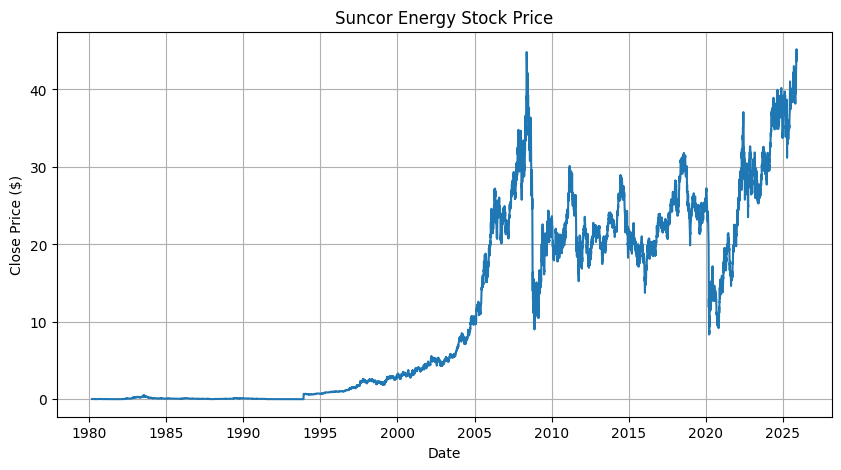

In [13]:
# Example: plot Suncor
plot_stock(energy_data["Suncor Energy"], "Suncor Energy")

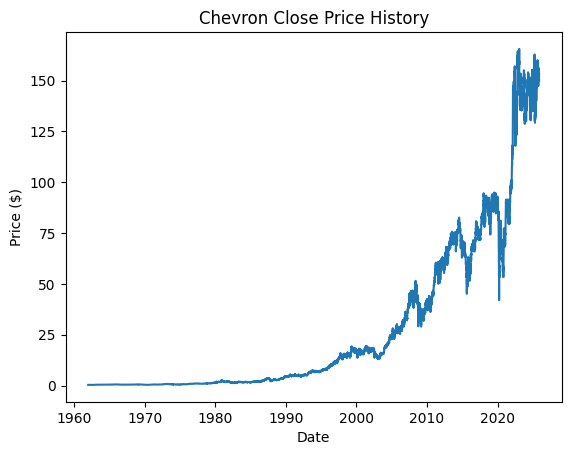

In [14]:
chevron_df = energy_data["Chevron"]
plt.plot(chevron_df['Date'], chevron_df['Close'])
plt.title("Chevron Close Price History")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

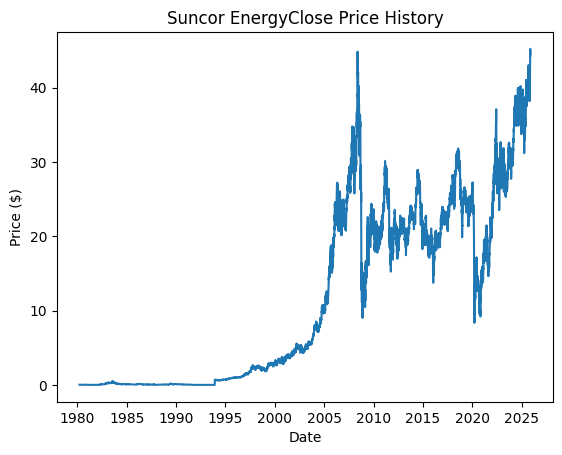

In [48]:
SU_df = energy_data["Suncor Energy"]
plt.plot(SU_df['Date'], SU_df['Close'])
plt.title("Suncor EnergyClose Price History")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

[*********************100%***********************]  5 of 5 completed


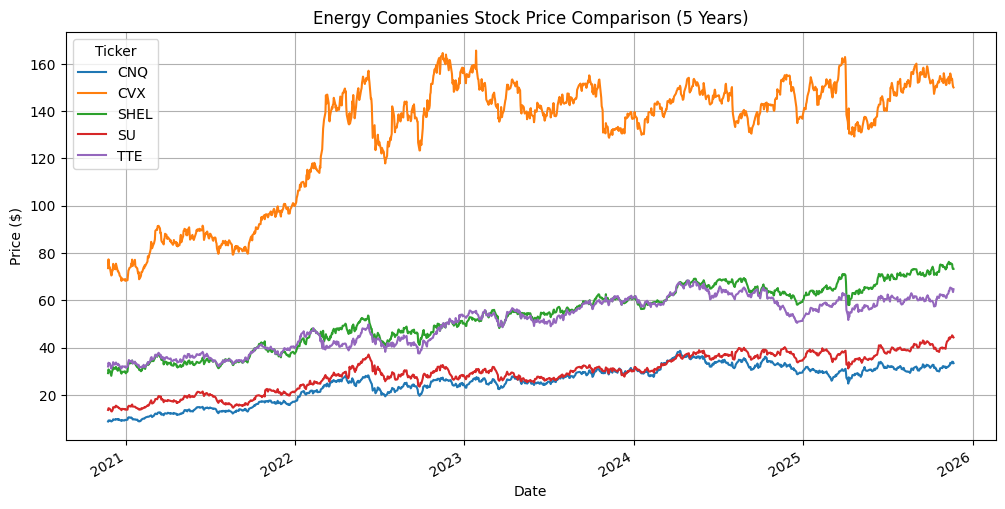

In [15]:
symbols = ["CVX", "TTE", "CNQ", "SU", "SHEL"]
df_all = yf.download(symbols, period="5y")["Close"]

df_all.plot(figsize=(12,6))
plt.title("Energy Companies Stock Price Comparison (5 Years)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(True)
plt.show()


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Use Webscraping to Extract Energy Companies Revenue Data

</center></p></h1>

In [ ]:
# ===============================
#  List of Energy Companies
# ===============================
tickers = {
    "Chevron": "CVX",
    "Total Energies": "TTE",
    "Canadian Natural Resources": "CNQ",
    "Suncor Energy": "SU",
    "Shell": "SHEL",
    "Exxon Mobil": "XOM"}

revenue_urls = {
    "Chevron": "https://www.macrotrends.net/stocks/charts/CVX/chevron/revenue",
    "Total Energies": "https://www.macrotrends.net/stocks/charts/TTE/total-energies/revenue",
    "Canadian Natural Resources": "https://www.macrotrends.net/stocks/charts/CNQ/canadian-natural-resources/revenue",
    "Suncor Energy": "https://www.macrotrends.net/stocks/charts/SU/suncor-energy/revenue",
    "Shell": "https://www.macrotrends.net/stocks/charts/SHEL/shell/revenue",
    "Exxon Mobil": "https://www.macrotrends.net/stocks/charts/XOM/exxon-mobil/revenue"}

header = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}


In [78]:
# ===============================
#  Scrape Revenue Function
# ===============================

def scrape_revenue(url):
    html = requests.get(url, headers=header).text
    soup = BeautifulSoup(html, "html.parser")

    print(soup.prettify()[:2000])  

    tables = soup.find_all("table")
    table = tables[0]   
    rows = table.find_all("tr")

    df = pd.DataFrame(columns=["Date", "Revenue"])

    for row in rows[1:]:
        cols = row.find_all("td")
        if len(cols) >= 2:
            date = cols[0].text.strip()
            revenue = cols[1].text.strip().replace(",", "").replace("$", "")
            df.loc[len(df)] = [date, revenue]

    df = df[df["Revenue"] != ""]
    return df

In [80]:
# ===============================
# Download Stock Data
# ===============================
energy_stock_data = {}
for name, symbol in tickers.items():
    print(f"\n📌 Downloading stock data for {name} ({symbol}) ...")
    stock = yf.Ticker(symbol)
    df = stock.history(period="max").reset_index()
    energy_stock_data[name] = df

      
    print(df.head())


📌 Downloading stock data for Chevron (CVX) ...
                       Date      Open      High       Low     Close  Volume  \
0 1962-01-02 00:00:00-05:00  0.306069  0.310983  0.306069  0.310983  105840   
1 1962-01-03 00:00:00-05:00  0.310983  0.311685  0.308877  0.310281  127680   
2 1962-01-04 00:00:00-05:00  0.310281  0.310281  0.307473  0.307473   75600   
3 1962-01-05 00:00:00-05:00  0.307473  0.308175  0.299751  0.299751  201600   
4 1962-01-08 00:00:00-05:00  0.299751  0.301155  0.296241  0.298347  126000   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  

📌 Downloading stock data for Total Energies (TTE) ...
                       Date      Open      High       Low     Close    Volume  \
0 1991-10-25 00:00:00-04:00  2.532404  2.577897  2.502076  2.562732  15468800   
1 1991-10-28 00:00:00-05:00  2.562732  2.577896  2.502075  2.517239   2785800   
2 199

In [ ]:
energy_revenue = {}

for name, url in revenue_urls.items():
    print(f"\nScraping revenue data for {name} ...")
    df_rev = scrape_revenue(url)
    energy_revenue[name] = df_rev
    print(df_rev.head())


Scraping revenue data for Chevron ...
<!DOCTYPE html>
<!--[if lt IE 7]>      <html class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js">
 <!--<![endif]-->
 <head>
  <meta charset="utf-8"/>
  <meta content="IE=edge,chrome=1" http-equiv="X-UA-Compatible"/>
  <link href="https://www.macrotrends.net/stocks/charts/CVX/chevron/revenue" rel="canonical"/>
  <title>
   Chevron Revenue 2011-2025 | CVX | MacroTrends
  </title>
  <link href="/assets/images/icons/FAVICON/macrotrends-favicon-96.png" rel="icon" type="image/x-icon"/>
  <meta content="Chevron annual/quarterly revenue history and growth rate from 2011 to 2025. Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services.  Revenue is the top line item on an income statement from which all costs an

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
  Plot Tesla Stock Graph


</center></p></h1>

In [ ]:
# ===============================
#  Make Graph Function
# ===============================
def make_graph(stock_data, revenue_data, company):
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        subplot_titles=("Historical Share Price", "Historical Revenue"),
        vertical_spacing=0.3 )

    fig.add_trace(
        go.Scatter(x=stock_data["Date"], y=stock_data["Close"], name="Share Price"),
        row=1, col=1)

    fig.add_trace(
        go.Bar(x=revenue_data["Date"], y=revenue_data["Revenue"], name="Revenue"),
        row=2, col=1)

    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($ Millions)", row=2, col=1)

    fig.update_layout(
        showlegend=False,
        height=900,
        title=company,
        xaxis_rangeslider_visible=True)
    fig.show()

In [ ]:
 #===============================
#  Compare All Companies
# ===============================
def compare_companies_closes(stock_dict):
    fig = go.Figure()
    for name, df in stock_dict.items():
        fig.add_trace(go.Scatter(x=df["Date"], y=df["Close"], name=name))
    fig.update_layout(title="Energy Companies Stock Price Comparison", height=600)
    fig.show()

In [ ]:
# ===============================
# Run All Graphs for Inspection
# ===============================
for company in tickers.keys():
    print(f"\n Plotting data for {company} ...")
    make_graph(energy_stock_data[company], energy_revenue[company], company)


📊 Plotting data for Chevron ...



📊 Plotting data for Total Energies ...



📊 Plotting data for Canadian Natural Resources ...



📊 Plotting data for Suncor Energy ...



📊 Plotting data for Shell ...



📊 Plotting data for Exxon Mobil ...


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Use Webscraping to Extract Energy Companies 

</center></p></h1>

In [ ]:
URL1 = 'https://www.macrotrends.net/stocks/charts/SU/suncor-energy-/stock-price-history'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

response = requests.get(URL1, headers=headers)

In [53]:

soup_text = BeautifulSoup(response.text, "html.parser")

print("=== با response.text ===")
print(soup_text.prettify()[:300])  



=== با response.text ===
<!DOCTYPE html>
<!--[if lt IE 7]>      <html class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js">
 <!--<![endif]-->
 <head>
 


In [54]:
tables1 = soup_text.find_all("table")
tables1

[<table class="historical_data_table table">
 <thead>
 <tr>
 <th colspan="7" style="text-align:center;">Suncor Energy  Historical Annual Stock Price Data</th>
 </tr>
 </thead>
 <thead>
 <tr>
 <th style="text-align:center;">Year</th>
 <th style="text-align:center;">Average Stock Price</th>
 <th style="text-align:center;">Year Open</th>
 <th style="text-align:center;">Year High</th>
 <th style="text-align:center;">Year Low</th>
 <th style="text-align:center;">Year Close</th>
 <th style="text-align:center;">Annual % Change</th>
 </tr>
 </thead>
 <tbody>
 <tr>
 <td style="text-align:center">2025</td>
 <td style="text-align:center;">38.1276</td>
 <td style="text-align:center;">34.8891</td>
 <td style="text-align:center;">45.2000</td>
 <td style="text-align:center;">30.8680</td>
 <td style="text-align:center;">44.3200</td>
 <td style="text-align:center; color:green">28.31%</td>
 </tr>
 <tr>
 <td style="text-align:center">2024</td>
 <td style="text-align:center;">35.3978</td>
 <td style="text

In [55]:
rows = soup_text.find_all('tr')
rows

[<tr>
 <th colspan="7" style="text-align:center;">Suncor Energy  Historical Annual Stock Price Data</th>
 </tr>,
 <tr>
 <th style="text-align:center;">Year</th>
 <th style="text-align:center;">Average Stock Price</th>
 <th style="text-align:center;">Year Open</th>
 <th style="text-align:center;">Year High</th>
 <th style="text-align:center;">Year Low</th>
 <th style="text-align:center;">Year Close</th>
 <th style="text-align:center;">Annual % Change</th>
 </tr>,
 <tr>
 <td style="text-align:center">2025</td>
 <td style="text-align:center;">38.1276</td>
 <td style="text-align:center;">34.8891</td>
 <td style="text-align:center;">45.2000</td>
 <td style="text-align:center;">30.8680</td>
 <td style="text-align:center;">44.3200</td>
 <td style="text-align:center; color:green">28.31%</td>
 </tr>,
 <tr>
 <td style="text-align:center">2024</td>
 <td style="text-align:center;">35.3978</td>
 <td style="text-align:center;">29.7862</td>
 <td style="text-align:center;">39.7877</td>
 <td style="tex

In [61]:
data = []
for row in rows[1:]:
    cols = row.find_all('td')
    cols_text = [col.text.strip() for col in cols]
    data.append(cols_text)

In [93]:
columns = ['Date', 'Average Stock Price', 'Year Open', 'Year High', 'Year Low', 'Year Close', 'Annual % Change']


SU_revenue= pd.DataFrame(data, columns=columns)
df_clean = SU_revenue.drop(0).copy()
df_clean.head(10)

,Date,Average Stock Price,Year Open,Year High,Year Low,Year Close,Annual % Change
1,2025,38.1276,34.8891,45.2000,30.8680,44.3200,28.31%
2,2024,35.3978,29.7862,39.7877,29.1647,34.5406,16.21%
3,2023,28.7358,26.7026,32.2739,25.0272,29.7213,5.97%
4,2022,28.1706,21.7655,36.7036,21.7655,28.0461,32.30%
5,2021,18.0111,13.6329,22.3177,13.6329,21.1981,54.94%
6,2020,14.6044,25.6394,26.9691,8.2779,13.6818,-46.67%
7,2019,24.0527,21.2323,26.3278,21.1439,25.6550,22.13%
8,2018,27.2600,27.2752,31.2773,19.6626,21.0070,-21.47%
9,2017,23.1045,23.2492,26.7506,20.3369,26.7506,15.84%
10,2016,19.0632,17.3089,23.5317,13.4161,23.0937,30.84%


In [ ]:


# Color based on positive (green) or negative (red) change
colors = ['green' if x >= 0 else 'red' for x in df_clean['Annual % Change']]

# Create Plotly Figure
fig = go.Figure()

# Bar chart for Annual % Change
fig.add_trace(go.Bar(
    x=df_clean['Date'],  # or df_clean['Year'] if available
    y=df_clean['Annual % Change'],
    marker_color=colors,
    text=df_clean['Annual % Change'].map(lambda x: f"{x}%"),
    textposition='auto',
    name='Annual % Change'))

# Layout with rangeslider
fig.update_layout(
    title="Annual % Change by Year",height=600,
    xaxis_title="Year",
    yaxis_title="Annual % Change (%)",
    template="plotly_white",
    xaxis=dict(
        type='category',      # Treat x-axis as categorical (years)
        tickmode='linear',
        rangeslider=dict(visible=True),  # Scroll/zoom slider
        fixedrange=False),
    yaxis=dict(fixedrange=False))

fig.show()


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
   Forecast 
   

</center></p></h1>

In [ ]:
def prophet_forecast(df, periods=90):
    """
    df: DataFrame with columns ['Date', 'Close']
    periods: Number of days to forecast
    Returns: model, forecast, RMSE
    """
    # Ensure datetime is proper and remove timezone
    df['Date'] = pd.to_datetime(df['Date'])
    df_prophet = df[['Date','Close']].rename(columns={'Date':'ds','Close':'y'})
    df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)  # remove timezone

    # Fit Prophet model
    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(df_prophet)

    # Forecast
    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    # Compute RMSE on historical
    merged = forecast[['ds','yhat']].merge(df_prophet, on='ds', how='left')
    hist = merged[merged['y'].notna()]
    rmse = math.sqrt(mean_squared_error(hist['y'], hist['yhat']))

    return model, forecast, rmse


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
   Alert Check 

</center></p></h1>

In [ ]:
# Run alert check with default threshold 10%
alerts = check_alerts(df)

print("⚠ Commodities with alerts:")
for commodity, change in alerts:
    print(f"{commodity}: {change:.2f}% change over last 10 periods")

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    -EMAIL

</center></p></h1>

In [ ]:


# Make sure you have a .env file with:
# EMAIL_USER=your_email@gmail.com
# EMAIL_PASS=your_app_password
# TO_EMAIL=recipient_email@gmail.com

def send_email_alert(alerts, forecast_file=None):
    """
    Send an email alert if any alerts are detected.

    Parameters:
        alerts : list of tuples
            List of (commodity_name, pct_change) exceeding threshold
        forecast_file : str, optional
            Path to attach a CSV/forecast file
    """
    if not alerts:
        print("✅ No alerts to send.")
        return

    load_dotenv()
    user = os.getenv("EMAIL_USER")
    password = os.getenv("EMAIL_PASS")
    to_email = os.getenv("TO_EMAIL")

    msg = EmailMessage()
    msg["From"] = user
    msg["To"] = to_email
    msg["Subject"] = "⚠️ Commodity Price Alert"

    body = "Price change exceeded threshold:\n\n"
    for commodity, pct in alerts:
        body += f"{commodity}: {pct:.2f}%\n"
    msg.set_content(body)

    if forecast_file and os.path.exists(forecast_file):
        with open(forecast_file, "rb") as f:
            msg.add_attachment(
                f.read(),
                maintype="application",
                subtype="octet-stream",
                filename=os.path.basename(forecast_file)
            )

    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as smtp:
        smtp.login(user, password)
        smtp.send_message(msg)

    print("✅ Email sent successfully.")


# Example usage
alerts = check_alerts(df_clean, price_column='Spot price CAD', threshold=5, lookback=5)
send_email_alert(alerts, forecast_file="forecast.csv")


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Automate 

    

</center></p></h1>

In [ ]:
def run_pipeline():
    urls = {
        "Lithium Carbonate": "https://tradingeconomics.com/commodity/lithium",
        "Sodium Carbonate": "https://tradingeconomics.com/commodity/soda-ash",
        "Calcium Carbonate": "https://tradingeconomics.com/commodity/calcium-carbonate"
    }

    print("🕸️ Scraping data...")
    data_file = scrape_tradingeconomics(urls)
    print("📈 Forecasting...")
    forecast_file = forecast_prices(data_file)
    print("📧 Sending email...")
    send_email(
        subject="Weekly Commodity Forecast Report",
        body="Attached is the latest forecast report for Lithium, Sodium, and Calcium Carbonates.",
        attachment_path=forecast_file
    )
    print("✅ Done!")


schedule.every().monday.at("08:00").do(run_pipeline)

if __name__ == "__main__":
    print("Scheduler started... Press Ctrl+C to exit")
    while True:
        schedule.run_pending()
        time.sleep(60)
